In [1]:
from qiskit import *

In [17]:
qr = QuantumRegister(3)
cr = ClassicalRegister(3)
circuit = QuantumCircuit(qr,cr)
circuit.x(0)
circuit.x(1)
circuit.ccx(0,1,2)
circuit.measure(qr, cr)
# circuit.measure(0,0)
# circuit.measure(1,1)
# circuit.measure(2,2)
# circuit.measure_all()
circuit.draw()




┌───┐     ┌─┐      
q9_0: ┤ X ├──■──┤M├──────
      ├───┤  │  └╥┘┌─┐   
q9_1: ┤ X ├──■───╫─┤M├───
      └───┘┌─┴─┐ ║ └╥┘┌─┐
q9_2: ─────┤ X ├─╫──╫─┤M├
           └───┘ ║  ║ └╥┘
c9: 3/═══════════╩══╩══╩═
                 0  1  2

Measurement results: {'111': 1024}


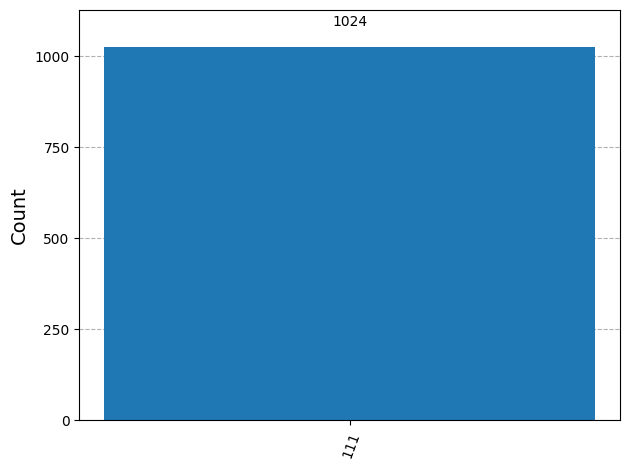

In [11]:
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram
simulator = BasicProvider().get_backend('basic_simulator') ## Create a basic quantum simulator
compiled_circuit = transpile(circuit, simulator) ## Transpile the circuit for the simulator
result = simulator.run(compiled_circuit, shots=1024).result() #Run the circuit multiple times (shots), Each shot represents one execution of the circuit 
# Print the raw measurement counts
print("Measurement results:", result.get_counts())
# Plot the histogram of measurement outcomes

plot_histogram(result.get_counts())

In [12]:
from qiskit.qasm2 import dumps, dump # use dumps for string, dump for file
qasm_str_v3 = dumps(circuit)
print(qasm_str_v3)

OPENQASM 2.0;
include "qelib1.inc";
qreg q4[3];
creg c4[3];
x q4[0];
x q4[1];
ccx q4[0],q4[1],q4[2];
measure q4[0] -> c4[0];
measure q4[1] -> c4[1];
measure q4[2] -> c4[2];
